In [2]:
# testing notebook
import polars as pl
import requests
import io
import pandas as pd
from kloppy.utils import github_resolve_raw_data_url

# 1. Load matches and squads data from IMPECT Open Data repository
match_url = github_resolve_raw_data_url(
    repository="ImpectAPI/open-data",
    branch="main",
    file="data/matches/matches_743.json"
)
squads_url = github_resolve_raw_data_url(
    repository="ImpectAPI/open-data",
    branch="main",
    file="data/squads/squads_743.json"
)

# 2. Load and process matches data
response = requests.get(match_url)
matches = (
    pl.read_json(io.StringIO(response.text))
    .unnest("matchDay")
    .rename({'iterationId': 'competitionId', 'id': 'matchId'})
    .drop(['idMappings', 'lastCalculationDate', 'name', 'available'])
    .with_columns([
        (pl.col("index") + 1).alias("matchDay")
    ])
    .drop("index")
)

response = requests.get(squads_url)
squads = (
    pl.read_json(io.StringIO(response.text))
    .drop(['type', 'gender', 'imageUrl', 'idMappings', 'access', 'countryId'])
)

matches = (
    matches
    .join(
        squads.rename({"name": "homeTeam"}),
        left_on="homeSquadId",
        right_on="id",
        how="left"
    )
    .join(
        squads.rename({"name": "awayTeam"}),
        left_on="awaySquadId",
        right_on="id",
        how="left"
    )
)




In [3]:
mask = (
    (matches["homeTeam"] == "Bayer 04 Leverkusen")
    & (matches["matchDay"] == 27)
)
matches.filter(mask)

competitionId,matchId,homeSquadId,awaySquadId,scheduledDate,matchDay,homeTeam,awayTeam
i64,i64,i64,i64,str,i64,str,str
743,123078,41,31,"""2024-03-30T14:30:00Z""",27,"""Bayer 04 Leverkusen""","""TSG 1899 Hoffenheim"""


In [4]:
from kloppy import impect
# lets load a game of Bayer Leverkusen vs FC Augsborn on 2024-05018
match_id = 123078 
dataset = impect.load_open_data(
    match_id=match_id,
    competition_id=743,
)

d:\SoccerImpectHackathon\.venv\Lib\site-packages\kloppy\_providers\impect.py:88: UserWarning: 

You are about to use IMPECT public data.
By using this data, you are agreeing to the user agreement. 
The user agreement can be found here: https://github.com/ImpectAPI/open-data/blob/main/LICENSE.pdf

  warnings.warn(


In [5]:
dataset[2]

PassEvent(qualifiers=[BodyPartQualifier(value=<BodyPart.RIGHT_FOOT: 'RIGHT_FOOT'>)])

In [ ]:
# Bayer Leverkusen passing network example
#check for index of first sub

df = (
    dataset
    .transform(to_coordinate_system="secondspectrum")  
    #.filter(lambda event: event.event_type.name in ["PASS"])
    .to_df(engine="pandas")  # or engine="polars"
)

# Add index as a column
df = df.reset_index(drop=False)

In [7]:
# Load players data from IMPECT Open Data repository
players_url = github_resolve_raw_data_url(
    repository="ImpectAPI/open-data",
    branch="main",
    file="data/players/players_743.json"
)

response = requests.get(players_url)
players = pl.read_json(io.StringIO(response.text))

# Create a mapping from player id to commonname
players_pd = players.select(['id', 'commonname']).to_pandas()
player_mapping = dict(zip(players_pd['id'], players_pd['commonname']))

# Convert player_id and receiver_player_id to numeric, coercing errors to NaN
df['player_id'] = pd.to_numeric(df['player_id'], errors='coerce')
df['receiver_player_id'] = pd.to_numeric(df['receiver_player_id'], errors='coerce')

# Map player names to df columns
df['player_name'] = df['player_id'].map(player_mapping)
df['receiver_player_name'] = df['receiver_player_id'].map(player_mapping)

In [8]:
player_mapping

{2: 'Andrej Kramaric',
 98: 'Joshua Kimmich',
 115: 'Emre Can',
 170: 'Eric Dier',
 183: 'Julian Weigl',
 200: 'Thomas Meunier',
 204: 'Leroy Sané',
 205: 'Péter Gulácsi',
 216: 'Thomas Müller',
 226: 'Tomas Koubek',
 231: 'Harry Kane',
 281: 'Granit Xhaka',
 296: 'Mats Hummels',
 309: 'Kingsley Coman',
 355: 'Emil Forsberg',
 356: 'Marcel Sabitzer',
 409: 'Raphaël Guerreiro',
 441: 'Pavel Kaderabek',
 444: 'Frederik Rönnow',
 460: 'Mario Götze',
 476: 'Jonathan Tah',
 495: 'Leonardo Bonucci',
 568: 'Nico Elvedi',
 582: 'Manuel Neuer',
 622: 'Matthias Ginter',
 647: 'Silvan Widmer',
 664: 'Florian Kainz',
 715: 'Marco Reus',
 732: 'Kevin Volland',
 735: 'Patrik Schick',
 754: 'Kevin Trapp',
 787: 'Thorgan Hazard',
 810: 'Christoph Kramer',
 817: 'Matus Bero',
 822: 'Karim Onisiwo',
 824: 'Julian Brandt',
 862: 'Roland Sallai',
 929: 'Eric-Maxim Choupo-Moting',
 930: 'Maximilian Philipp',
 943: 'Dominik Kohr',
 944: 'Timothy Chandler',
 957: 'Yannick Gerhardt',
 968: 'Michael Gregoritsc

In [9]:
df['player_name']

0         Maximilian Beier
1              Tim Drexler
2              Tim Drexler
3               Ozan Kabak
4               Ozan Kabak
               ...        
3448    Florian Grillitsch
3449        Lukas Hradecky
3450        Lukas Hradecky
3451        Lukas Hradecky
3452                   NaN
Name: player_name, Length: 3453, dtype: object

In [10]:
print("\n" + "=" * 50)
print("DATAFRAME COLUMNS")
print("=" * 50)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns}")
print(f"\nFirst few rows:")
df.head()


DATAFRAME COLUMNS
Shape: 3453 rows × 25 columns

Columns: Index(['index', 'event_id', 'event_type', 'period_id', 'timestamp',
       'end_timestamp', 'ball_state', 'ball_owning_team', 'team_id',
       'player_id', 'coordinates_x', 'coordinates_y', 'end_coordinates_x',
       'end_coordinates_y', 'receiver_player_id', 'body_part_type',
       'set_piece_type', 'result', 'success', 'is_under_pressure', 'pass_type',
       'duel_type', 'goalkeeper_type', 'player_name', 'receiver_player_name'],
      dtype='object')

First few rows:


,index,event_id,event_type,period_id,timestamp,end_timestamp,ball_state,ball_owning_team,team_id,player_id,...,body_part_type,set_piece_type,result,success,is_under_pressure,pass_type,duel_type,goalkeeper_type,player_name,receiver_player_name
0,0,4608883390,PASS,1,0 days 00:00:00,0 days 00:00:00.720000,alive,31,31,49782.0,...,RIGHT_FOOT,KICK_OFF,COMPLETE,True,None,None,None,None,Maximilian Beier,Tim Drexler
1,1,4608883391,GENERIC:RECEPTION,1,0 days 00:00:00.720000,NaT,alive,31,31,104321.0,...,None,None,None,None,None,None,None,None,Tim Drexler,NaN
2,2,4608883392,PASS,1,0 days 00:00:00.720100,0 days 00:00:01.760000,alive,31,31,104321.0,...,RIGHT_FOOT,None,COMPLETE,True,None,None,None,None,Tim Drexler,Ozan Kabak
3,3,4608883393,GENERIC:RECEPTION,1,0 days 00:00:01.760000,NaT,alive,31,31,2498.0,...,None,None,None,None,None,None,None,None,Ozan Kabak,NaN
4,4,4608883394,PASS,1,0 days 00:00:01.760100,0 days 00:00:04.494000,alive,31,31,2498.0,...,RIGHT_FOOT,None,INCOMPLETE,False,None,None,None,None,Ozan Kabak,NaN


In [ ]:
# Only looking at bayer leverkusen
# Get all passes by Bayer Leverkusen until the first substitution, so we have how our starters behaved for the first 60'
sub = df.loc[df["event_type"] == "SUBSTITUTION"].loc[df["team_id"] == '41'].index[0]

In [ ]:
print(sub) # index in df where we had our first sub in the 58' (hoffman off)

2331


In [ ]:
df_bayer = df[(df.event_type == 'PASS') & (df.team_id == '41') & (df.set_piece_type != "THROW_IN")]
df_bayer = df_bayer[df_bayer['index'] < sub]

# Taking necessary columns - now using player_name and receiver_player_name
df_pass = df_bayer[['coordinates_x', 'coordinates_y', 'end_coordinates_x', 'end_coordinates_y', "player_name", "receiver_player_name"]].copy()

# Remove rows where player_name or receiver_player_name are NaN
df_pass = df_pass.dropna(subset=['player_name', 'receiver_player_name'])

In [14]:
df_bayer

,index,event_id,event_type,period_id,timestamp,end_timestamp,ball_state,ball_owning_team,team_id,player_id,...,body_part_type,set_piece_type,result,success,is_under_pressure,pass_type,duel_type,goalkeeper_type,player_name,receiver_player_name
6,6,4608883396,PASS,1,0 days 00:00:04.494100,0 days 00:00:07.124000,alive,31,41,53110.0,...,HEAD,None,INCOMPLETE,False,True,HEAD_PASS,None,None,Piero Hincapié,Alejandro Grimaldo
8,8,4608883398,PASS,1,0 days 00:00:07.124100,0 days 00:00:09.455000,alive,31,41,5616.0,...,HEAD,None,INCOMPLETE,False,True,HEAD_PASS,None,None,Alejandro Grimaldo,NaN
15,15,4608883405,PASS,1,0 days 00:00:24.644999,0 days 00:00:25.300999,alive,41,41,5616.0,...,RIGHT_FOOT,None,COMPLETE,True,True,None,None,None,Alejandro Grimaldo,Jonathan Tah
17,17,4608883407,PASS,1,0 days 00:00:25.301100,0 days 00:00:26.632000,alive,41,41,476.0,...,RIGHT_FOOT,None,INCOMPLETE,False,True,CHIPPED_PASS,None,None,Jonathan Tah,NaN
23,23,4608883413,PASS,1,0 days 00:00:29.910099,0 days 00:00:31.433999,alive,31,41,476.0,...,HEAD,None,INCOMPLETE,False,True,HEAD_PASS,None,None,Jonathan Tah,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2291,2291,4608885640,PASS,2,0 days 00:08:39.782100,0 days 00:08:41.081000,alive,41,41,1169.0,...,RIGHT_FOOT,None,COMPLETE,True,None,None,None,None,Jonas Hofmann,Florian Wirtz
2298,2298,4608885647,PASS,2,0 days 00:09:04.917000,0 days 00:09:06.100000,alive,41,41,64023.0,...,RIGHT_FOOT,None,COMPLETE,True,True,None,None,None,Florian Wirtz,Alejandro Grimaldo
2301,2301,4608885650,PASS,2,0 days 00:09:07.412000,0 days 00:09:08.825000,alive,41,41,5616.0,...,RIGHT_FOOT,None,INCOMPLETE,False,None,HIGH_PASS,None,None,Alejandro Grimaldo,NaN
2304,2304,4608885653,PASS,2,0 days 00:09:35.870000,0 days 00:09:37.819000,alive,41,41,1169.0,...,RIGHT_FOOT,CORNER_KICK,INCOMPLETE,False,None,SHOT_ASSIST,None,None,Jonas Hofmann,Jonathan Tah


In [15]:
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Pitch
import pandas as pd

# Create a list to collect player data
player_data = []

for name in df_pass["player_name"].unique():
    passx = df_pass.loc[df_pass["player_name"] == name]["coordinates_x"].to_numpy()
    recx = df_pass.loc[df_pass["receiver_player_name"] == name]["end_coordinates_x"].to_numpy()
    passy = df_pass.loc[df_pass["player_name"] == name]["coordinates_y"].to_numpy()
    recy = df_pass.loc[df_pass["receiver_player_name"] == name]["end_coordinates_y"].to_numpy()
    
    pass_count = len(passx) + len(recx)  # Count total passes and receptions
    
    player_data.append({
        "player_name": name,
        "coordinates_x": np.mean(np.concatenate([passx, recx])) if len(passx) > 0 or len(recx) > 0 else 0,
        "coordinates_y": np.mean(np.concatenate([passy, recy])) if len(passy) > 0 or len(recy) > 0 else 0,
        "no": pass_count
    })

# Create DataFrame from list
scatter_df = pd.DataFrame(player_data)

# Calculate marker size based on pass count
scatter_df['marker_size'] = (scatter_df['no'] / scatter_df['no'].max() * 1500)

In [16]:
player_data

[{'player_name': 'Piero Hincapié',
  'coordinates_x': np.float64(8.277049180327868),
  'coordinates_y': np.float64(19.040983606557376),
  'no': 122},
 {'player_name': 'Alejandro Grimaldo',
  'coordinates_x': np.float64(18.82738095238095),
  'coordinates_y': np.float64(22.509523809523813),
  'no': 84},
 {'player_name': 'Edmond Tapsoba',
  'coordinates_x': np.float64(7.807339449541284),
  'coordinates_y': np.float64(-18.710091743119264),
  'no': 109},
 {'player_name': 'Granit Xhaka',
  'coordinates_x': np.float64(11.958139534883722),
  'coordinates_y': np.float64(-0.4984496124031011),
  'no': 129},
 {'player_name': 'Jonathan Tah',
  'coordinates_x': np.float64(0.8437499999999998),
  'coordinates_y': np.float64(-2.1107142857142858),
  'no': 112},
 {'player_name': 'Robert Andrich',
  'coordinates_x': np.float64(12.561616161616161),
  'coordinates_y': np.float64(6.8828282828282825),
  'no': 99},
 {'player_name': 'Jeremie Frimpong',
  'coordinates_x': np.float64(23.64),
  'coordinates_y': np

In [17]:
df_pass

,coordinates_x,coordinates_y,end_coordinates_x,end_coordinates_y,player_name,receiver_player_name
6,-32.4,21.3,-43.7,24.7,Piero Hincapié,Alejandro Grimaldo
15,-46.8,16.2,-48.1,13.5,Alejandro Grimaldo,Jonathan Tah
42,-43.7,5.4,-36.3,10.1,Edmond Tapsoba,Granit Xhaka
44,-36.3,10.1,-36.3,16.2,Granit Xhaka,Robert Andrich
62,-34.0,-26.5,-34.0,-32.9,Granit Xhaka,Jeremie Frimpong
...,...,...,...,...,...,...
2286,-12.6,-24.0,17.7,-29.3,Jonas Hofmann,Jeremie Frimpong
2289,23.7,-15.3,27.1,-31.9,Jeremie Frimpong,Jonas Hofmann
2291,27.1,-31.9,34.8,-31.6,Jonas Hofmann,Florian Wirtz
2298,51.0,-23.8,45.5,-31.8,Florian Wirtz,Alejandro Grimaldo


In [18]:
#counting passes between players
df_pass["pair_key"] = df_pass.apply(lambda x: "_".join(sorted([x["player_name"], x["receiver_player_name"]])), axis=1)
lines_df = df_pass.groupby(["pair_key"]).size().reset_index(name='pass_count')
#setting a treshold. You can try to investigate how it changes when you change it.
lines_df = lines_df[lines_df['pass_count']>2]

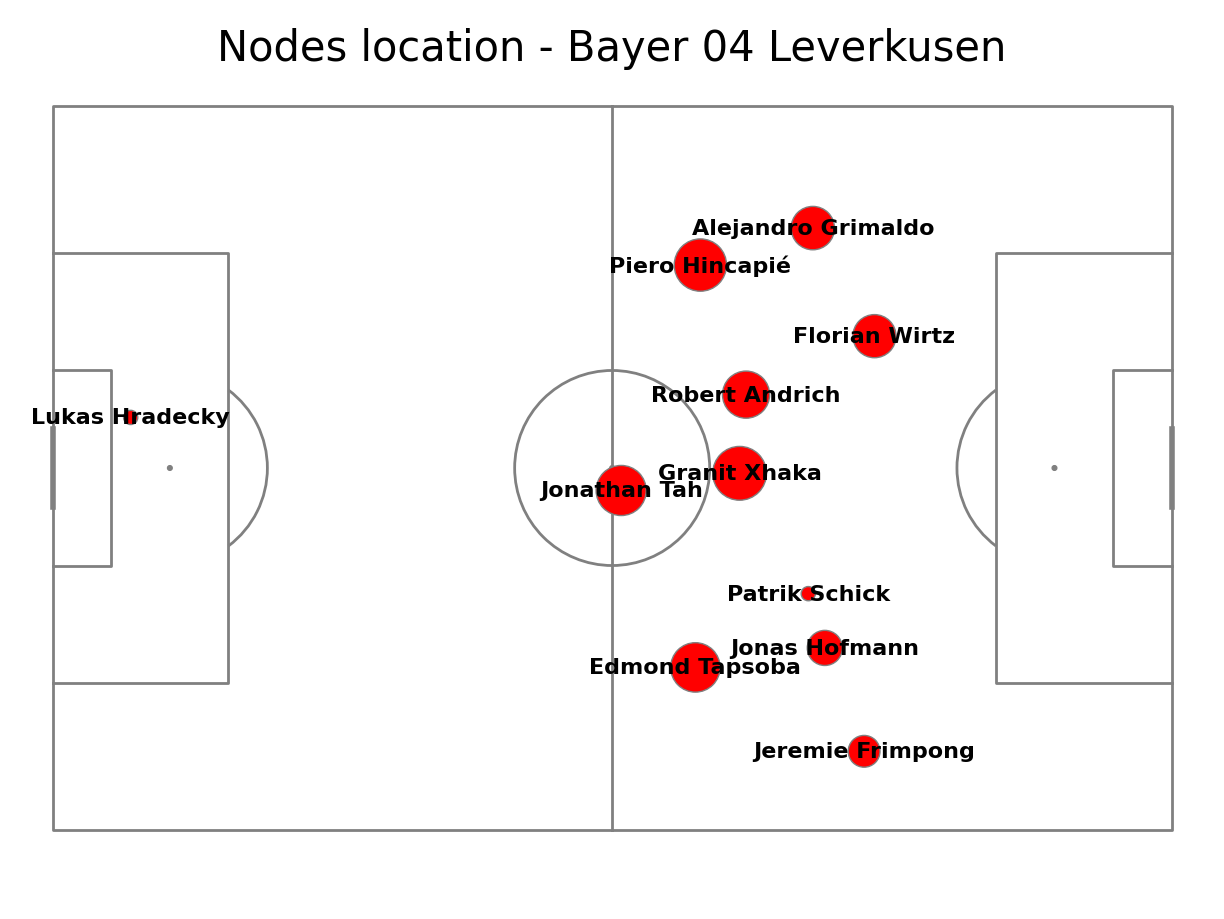

In [19]:
#Drawing pitch
pitch = Pitch(pitch_type='impect',line_color='grey')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
#Scatter the location on the pitch
pitch.scatter(scatter_df.coordinates_x, scatter_df.coordinates_y, s=scatter_df.marker_size, color='red', edgecolors='grey', linewidth=1, alpha=1, ax=ax["pitch"], zorder = 3)
#annotating player name
for i, row in scatter_df.iterrows():
    pitch.annotate(row.player_name, xy=(row.coordinates_x, row.coordinates_y), c='black', va='center', ha='center', weight = "bold", size=16, ax=ax["pitch"], zorder = 4)

fig.suptitle("Nodes location - Bayer 04 Leverkusen", fontsize = 30)
plt.show()

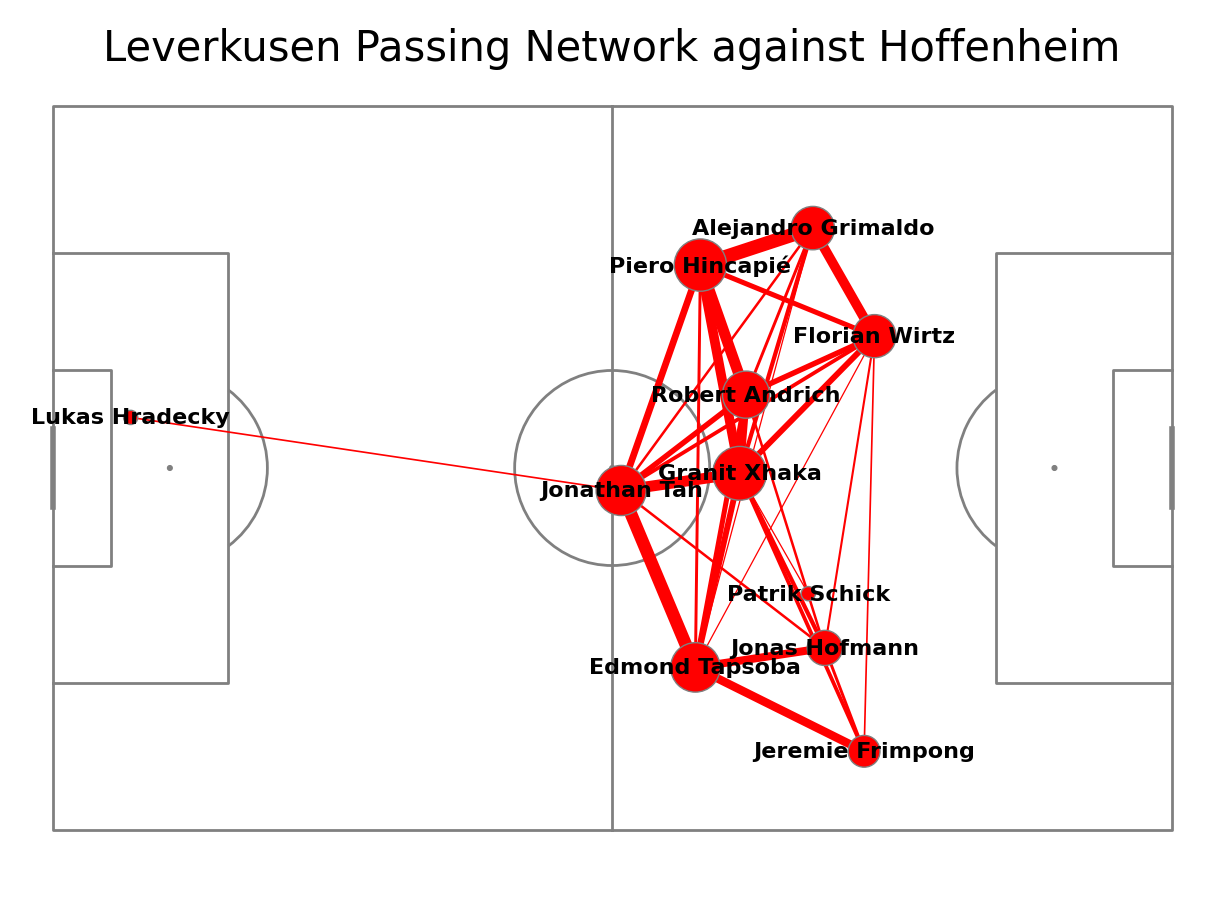

In [20]:
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
pitch.scatter(scatter_df.coordinates_x, scatter_df.coordinates_y, s=scatter_df.marker_size, color='red', edgecolors='grey', linewidth=1, alpha=1, ax=ax["pitch"], zorder = 3)
for i, row in scatter_df.iterrows():
    pitch.annotate(row.player_name, xy=(row.coordinates_x, row.coordinates_y), c='black', va='center', ha='center', weight = "bold", size=16, ax=ax["pitch"], zorder = 4)

for i, row in lines_df.iterrows():
        player1 = row["pair_key"].split("_")[0]
        player2 = row['pair_key'].split("_")[1]
        #take the average location of players to plot a line between them
        player1_x = scatter_df.loc[scatter_df["player_name"] == player1]['coordinates_x'].iloc[0]
        player1_y = scatter_df.loc[scatter_df["player_name"] == player1]['coordinates_y'].iloc[0]
        player2_x = scatter_df.loc[scatter_df["player_name"] == player2]['coordinates_x'].iloc[0]
        player2_y = scatter_df.loc[scatter_df["player_name"] == player2]['coordinates_y'].iloc[0]
        num_passes = row["pass_count"]
        #adjust the line width so that the more passes, the wider the line
        line_width = (num_passes / lines_df['pass_count'].max() * 10)
        #plot lines on the pitch
        pitch.lines(player1_x, player1_y, player2_x, player2_y,
                        alpha=1, lw=line_width, zorder=2, color="red", ax = ax["pitch"])

fig.suptitle("Leverkusen Passing Network against Hoffenheim", fontsize = 30)
plt.show()

In [21]:
df_pass

,coordinates_x,coordinates_y,end_coordinates_x,end_coordinates_y,player_name,receiver_player_name,pair_key
6,-32.4,21.3,-43.7,24.7,Piero Hincapié,Alejandro Grimaldo,Alejandro Grimaldo_Piero Hincapié
15,-46.8,16.2,-48.1,13.5,Alejandro Grimaldo,Jonathan Tah,Alejandro Grimaldo_Jonathan Tah
42,-43.7,5.4,-36.3,10.1,Edmond Tapsoba,Granit Xhaka,Edmond Tapsoba_Granit Xhaka
44,-36.3,10.1,-36.3,16.2,Granit Xhaka,Robert Andrich,Granit Xhaka_Robert Andrich
62,-34.0,-26.5,-34.0,-32.9,Granit Xhaka,Jeremie Frimpong,Granit Xhaka_Jeremie Frimpong
...,...,...,...,...,...,...,...
2286,-12.6,-24.0,17.7,-29.3,Jonas Hofmann,Jeremie Frimpong,Jeremie Frimpong_Jonas Hofmann
2289,23.7,-15.3,27.1,-31.9,Jeremie Frimpong,Jonas Hofmann,Jeremie Frimpong_Jonas Hofmann
2291,27.1,-31.9,34.8,-31.6,Jonas Hofmann,Florian Wirtz,Florian Wirtz_Jonas Hofmann
2298,51.0,-23.8,45.5,-31.8,Florian Wirtz,Alejandro Grimaldo,Alejandro Grimaldo_Florian Wirtz


In [ ]:
# Case study around decentralised football, based on a study by
# Thomas Grund’s 2012 study, "Network structure and team performance: The case of English Premier League,"
# Evaluate how successful teams tend to play in a more decentralized passing structure.
# A centralized stucture is not desirable as it depends heavily one one or two main players
def centralisation_eval(df):
    """ Input a dataframe consisting of the passes used to make the passing network"""
    # Strength centralization based on Grund (2012).
    if df is None or df.empty:
        return 0.0
    if "receiver_player_name" not in df.columns:
        raise ValueError("df must include a receiver_player_name column")
    # P_i: total passes received by player i (weights w_ij aggregated).
    passes_received = df.groupby("receiver_player_name").size()
    if passes_received.empty:
        return 0.0
    n_players = passes_received.shape[0]
    if n_players <= 1:
        return 0.0
    p_star = passes_received.max()
    p_sum = passes_received.sum()
    if p_sum == 0:
        return 0.0
    numerator = (p_star - passes_received).sum()
    denominator = (n_players - 1) * p_sum

    # turn value into a percentage
    return round(float(numerator / denominator)*100, 2)


centralisation_eval(df_pass)
# This is a pretty low value which is to be expected of the best team that season and one known for 
# playing free flowing decentralized football

6.71

In [27]:
# Lets test with a game from Koln, the second worst team that season
koln_mask = (
    (matches["homeTeam"] == "1. FC Köln")
)
matches.filter(koln_mask)

competitionId,matchId,homeSquadId,awaySquadId,scheduledDate,matchDay,homeTeam,awayTeam
i64,i64,i64,i64,str,i64,str,str
743,122849,27,30,"""2023-08-26T13:30:00Z""",2,"""1. FC Köln""","""VfL Wolfsburg"""
743,122870,27,31,"""2023-09-16T13:30:00Z""",4,"""1. FC Köln""","""TSG 1899 Hoffenheim"""
743,122886,27,46,"""2023-09-30T13:30:00Z""",6,"""1. FC Köln""","""VfB Stuttgart"""
743,122908,27,32,"""2023-10-22T13:30:00Z""",8,"""1. FC Köln""","""Borussia Mönchengladbach"""
743,122924,27,39,"""2023-11-04T14:30:00Z""",10,"""1. FC Köln""","""FC Augsburg"""
…,…,…,…,…,…,…,…
743,123064,27,37,"""2024-03-15T19:30:00Z""",26,"""1. FC Köln""","""RasenBallsport Leipzig"""
743,123086,27,416,"""2024-04-06T13:30:00Z""",28,"""1. FC Köln""","""VfL Bochum"""
743,123107,27,36,"""2024-04-20T13:30:00Z""",30,"""1. FC Köln""","""SV Darmstadt 98"""


In [ ]:
#Lets choose matchId 123119, Koln at home vs SC Freiburg who were a mid table team that season
# May 4th 2024
match_id = 123119 
koln_dataset = impect.load_open_data(
    match_id=match_id,
    competition_id=743,
)

koln_freiburg_df = (
    koln_dataset
    .transform(to_coordinate_system="secondspectrum")  
    #.filter(lambda event: event.event_type.name in ["PASS"])
    .to_df(engine="pandas")  # or engine="polars"
)

# Add index as a column
koln_freiburg_df = koln_freiburg_df.reset_index(drop=False)


# Load players data from IMPECT Open Data repository
players_url = github_resolve_raw_data_url(
    repository="ImpectAPI/open-data",
    branch="main",
    file="data/players/players_743.json"
)

response = requests.get(players_url)
players = pl.read_json(io.StringIO(response.text))

# Create a mapping from player id to commonname
players_pd = players.select(['id', 'commonname']).to_pandas()
player_mapping = dict(zip(players_pd['id'], players_pd['commonname']))

# Convert player_id and receiver_player_id to numeric, coercing errors to NaN
koln_freiburg_df['player_id'] = pd.to_numeric(koln_freiburg_df['player_id'], errors='coerce')
koln_freiburg_df['receiver_player_id'] = pd.to_numeric(koln_freiburg_df['receiver_player_id'], errors='coerce')

# Map player names to df columns
koln_freiburg_df['player_name'] = koln_freiburg_df['player_id'].map(player_mapping)
koln_freiburg_df['receiver_player_name'] = koln_freiburg_df['receiver_player_id'].map(player_mapping)

#get first sub index, 57' Chabot out
koln_sub = koln_freiburg_df.loc[koln_freiburg_df["event_type"] == "SUBSTITUTION"].loc[koln_freiburg_df["team_id"] == '27'].index[0]

df_koln = koln_freiburg_df[(koln_freiburg_df.event_type == 'PASS') & (koln_freiburg_df.team_id == '27') & (koln_freiburg_df.set_piece_type != "THROW_IN")]
df_koln = df_koln[df_koln['index'] < koln_sub]

# Taking necessary columns - now using player_name and receiver_player_name
df_pass_koln = df_koln[['coordinates_x', 'coordinates_y', 'end_coordinates_x', 'end_coordinates_y', "player_name", "receiver_player_name"]].copy()

# Remove rows where player_name or receiver_player_name are NaN
df_pass_koln = df_pass_koln.dropna(subset=['player_name', 'receiver_player_name'])

print(centralisation_eval(df_pass_koln))
# Ok so Koln actually gets a pretty low score, contrary to my hypothesis
# This was actually a game where koln played really well and were very much the superior team statistically
#Lets visualize real quick

6.01


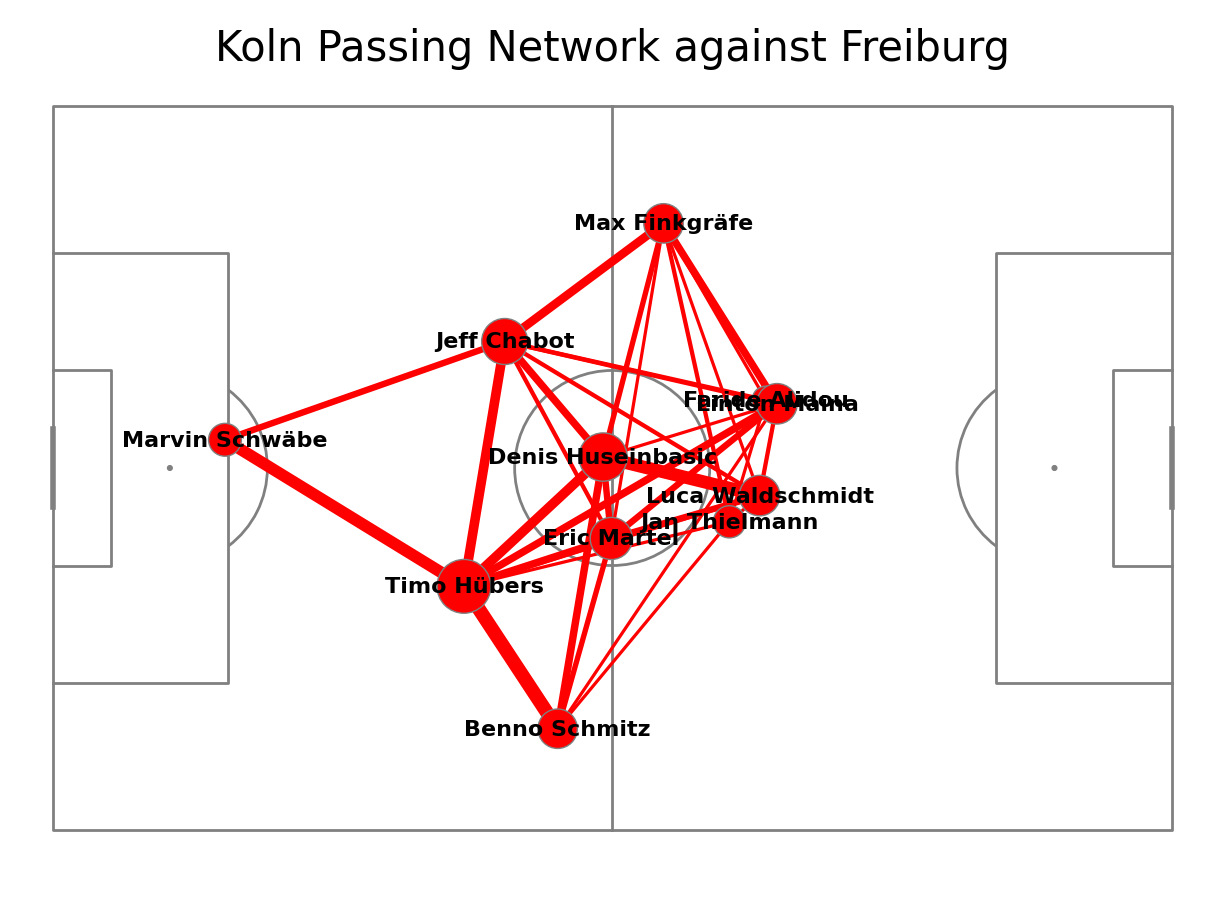

In [45]:
# Koln pass network #TODO: make it reusable
df_pass_koln["pair_key"] = df_pass_koln.apply(lambda x: "_".join(sorted([x["player_name"], x["receiver_player_name"]])), axis=1)
lines_df = df_pass_koln.groupby(["pair_key"]).size().reset_index(name='pass_count')
#setting a treshold. You can try to investigate how it changes when you change it.
lines_df = lines_df[lines_df['pass_count']>2]

###
# Create a list to collect player data
koln_player_data = []

for name in df_pass_koln["player_name"].unique():
    passx = df_pass_koln.loc[df_pass_koln["player_name"] == name]["coordinates_x"].to_numpy()
    recx = df_pass_koln.loc[df_pass_koln["receiver_player_name"] == name]["end_coordinates_x"].to_numpy()
    passy = df_pass_koln.loc[df_pass_koln["player_name"] == name]["coordinates_y"].to_numpy()
    recy = df_pass_koln.loc[df_pass_koln["receiver_player_name"] == name]["end_coordinates_y"].to_numpy()
    
    pass_count = len(passx) + len(recx)  # Count total passes and receptions
    
    koln_player_data.append({
        "player_name": name,
        "coordinates_x": np.mean(np.concatenate([passx, recx])) if len(passx) > 0 or len(recx) > 0 else 0,
        "coordinates_y": np.mean(np.concatenate([passy, recy])) if len(passy) > 0 or len(recy) > 0 else 0,
        "no": pass_count
    })

# Create DataFrame from list
scatter_df = pd.DataFrame(koln_player_data)

# Calculate marker size based on pass count
scatter_df['marker_size'] = (scatter_df['no'] / scatter_df['no'].max() * 1500)
####


pitch = Pitch(pitch_type='impect',line_color='grey')

fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
pitch.scatter(scatter_df.coordinates_x, scatter_df.coordinates_y, s=scatter_df.marker_size, color='red', edgecolors='grey', linewidth=1, alpha=1, ax=ax["pitch"], zorder = 3)
for i, row in scatter_df.iterrows():
    pitch.annotate(row.player_name, xy=(row.coordinates_x, row.coordinates_y), c='black', va='center', ha='center', weight = "bold", size=16, ax=ax["pitch"], zorder = 4)

for i, row in lines_df.iterrows():
        player1 = row["pair_key"].split("_")[0]
        player2 = row['pair_key'].split("_")[1]
        #take the average location of players to plot a line between them
        player1_x = scatter_df.loc[scatter_df["player_name"] == player1]['coordinates_x'].iloc[0]
        player1_y = scatter_df.loc[scatter_df["player_name"] == player1]['coordinates_y'].iloc[0]
        player2_x = scatter_df.loc[scatter_df["player_name"] == player2]['coordinates_x'].iloc[0]
        player2_y = scatter_df.loc[scatter_df["player_name"] == player2]['coordinates_y'].iloc[0]
        num_passes = row["pass_count"]
        #adjust the line width so that the more passes, the wider the line
        line_width = (num_passes / lines_df['pass_count'].max() * 10)
        #plot lines on the pitch
        pitch.lines(player1_x, player1_y, player2_x, player2_y,
                        alpha=1, lw=line_width, zorder=2, color="red", ax = ax["pitch"])

fig.suptitle("Koln Passing Network against Freiburg", fontsize = 30)
plt.show()

In [47]:
# Checking for Freiburg now:
#get first sub index
freiburg_sub = koln_freiburg_df.loc[koln_freiburg_df["event_type"] == "SUBSTITUTION"].loc[koln_freiburg_df["team_id"] == '34'].index[0]

df_freiburg = koln_freiburg_df[(koln_freiburg_df.event_type == 'PASS') & (koln_freiburg_df.team_id == '34') & (koln_freiburg_df.set_piece_type != "THROW_IN")]
df_freiburg = df_freiburg[df_freiburg['index'] < freiburg_sub]

# Taking necessary columns - now using player_name and receiver_player_name
df_pass_freiburg = df_freiburg[['coordinates_x', 'coordinates_y', 'end_coordinates_x', 'end_coordinates_y', "player_name", "receiver_player_name"]].copy()

# Remove rows where player_name or receiver_player_name are NaN
df_pass_freiburg = df_pass_freiburg.dropna(subset=['player_name', 'receiver_player_name'])

print(centralisation_eval(df_pass_freiburg))

5.71


In [ ]:
# Freiburg pass network
df_pass_freiburg["pair_key"] = df_pass_freiburg.apply(lambda x: "_".join(sorted([x["player_name"], x["receiver_player_name"]])), axis=1)
lines_df = df_pass_freiburg.groupby(["pair_key"]).size().reset_index(name='pass_count')
#setting a treshold. You can try to investigate how it changes when you change it.
lines_df = lines_df[lines_df['pass_count']>2]

###
# Create a list to collect player data
freiburg_player_data = []

for name in df_pass_freiburg["player_name"].unique():
    passx = df_pass_freiburg.loc[df_pass_freiburg["player_name"] == name]["coordinates_x"].to_numpy()
    recx = df_pass_freiburg.loc[df_pass_freiburg["receiver_player_name"] == name]["end_coordinates_x"].to_numpy()
    passy = df_pass_freiburg.loc[df_pass_freiburg["player_name"] == name]["coordinates_y"].to_numpy()
    recy = df_pass_freiburg.loc[df_pass_freiburg["receiver_player_name"] == name]["end_coordinates_y"].to_numpy()
    
    pass_count = len(passx) + len(recx)  # Count total passes and receptions
    
    freiburg_player_data.append({
        "player_name": name,
        "coordinates_x": np.mean(np.concatenate([passx, recx])) if len(passx) > 0 or len(recx) > 0 else 0,
        "coordinates_y": np.mean(np.concatenate([passy, recy])) if len(passy) > 0 or len(recy) > 0 else 0,
        "no": pass_count
    })

# Create DataFrame from list
scatter_df = pd.DataFrame(freiburg_player_data)

# Calculate marker size based on pass count
scatter_df['marker_size'] = (scatter_df['no'] / scatter_df['no'].max() * 1500)
####


pitch = Pitch(pitch_type='impect',line_color='grey')

fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
pitch.scatter(scatter_df.coordinates_x, scatter_df.coordinates_y, s=scatter_df.marker_size, color='red', edgecolors='grey', linewidth=1, alpha=1, ax=ax["pitch"], zorder = 3)
for i, row in scatter_df.iterrows():
    pitch.annotate(row.player_name, xy=(row.coordinates_x, row.coordinates_y), c='black', va='center', ha='center', weight = "bold", size=16, ax=ax["pitch"], zorder = 4)

for i, row in lines_df.iterrows():
        player1 = row["pair_key"].split("_")[0]
        player2 = row['pair_key'].split("_")[1]
        #take the average location of players to plot a line between them
        player1_x = scatter_df.loc[scatter_df["player_name"] == player1]['coordinates_x'].iloc[0]
        player1_y = scatter_df.loc[scatter_df["player_name"] == player1]['coordinates_y'].iloc[0]
        player2_x = scatter_df.loc[scatter_df["player_name"] == player2]['coordinates_x'].iloc[0]
        player2_y = scatter_df.loc[scatter_df["player_name"] == player2]['coordinates_y'].iloc[0]
        num_passes = row["pass_count"]
        #adjust the line width so that the more passes, the wider the line
        line_width = (num_passes / lines_df['pass_count'].max() * 10)
        #plot lines on the pitch
        pitch.lines(player1_x, player1_y, player2_x, player2_y,
                        alpha=1, lw=line_width, zorder=2, color="red", ax = ax["pitch"])

fig.suptitle("Freiburg Passing Network against Köln", fontsize = 30)
plt.show()